# Hockey Poisson Simulation

### Goals
- Using xG values for and against, resimulate all 82 Toronto Maple Leafs regular season games from the 2024-2025 season using the Poisson distribution.
- Compare actual results to expected results over the course of the season. Treat overtime losses as regulation losses, for simplicity.
- Provide written analysis of methods and results.


In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/leafs_2425.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


All libraries used for this lab

In [2]:
import numpy as np
from scipy.stats import poisson
from io import StringIO
import re
import matplotlib.pyplot as plt

# Part 1: Formulate the data

Start by understanding what is in the data set

In [3]:
print("Available columns:")
print(df.columns.tolist())

# Display basic info about the DataFrame (columns, data types, non-null counts)
print("\nDataFrame info:")
df.info()
#non null count is just to see if there is any missing data within any of the columns, there is not.

# This print function just lets me see the info a little more so I can understand the order
print("\nFirst 5 rows of data:")
print(df.head())

Available columns:
['Game', 'Team', 'GF', 'GA', 'xGF', 'xGA']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Game    82 non-null     object 
 1   Team    82 non-null     object 
 2   GF      82 non-null     int64  
 3   GA      82 non-null     int64  
 4   xGF     82 non-null     float64
 5   xGA     82 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.0+ KB

First 5 rows of data:
                                       Game                 Team  GF  GA  \
0   2024-10-09 - Maple Leafs 0, Canadiens 1  Toronto Maple Leafs   0   1   
1      2024-10-10 - Maple Leafs 4, Devils 2  Toronto Maple Leafs   4   2   
2    2024-10-12 - Penguins 2, Maple Leafs 4  Toronto Maple Leafs   4   2   
3       2024-10-16 - Kings 2, Maple Leafs 6  Toronto Maple Leafs   6   2   
4     2024-10-19 - Rangers 4, Maple Leafs 1  Toronto Maple

Make sure actual goals for (GF) and against (GA) includes overtime goals

Distinguish if Leafs win (1) or lose (0), includes overtime wins/losses as regulation

Within this, `for idx, row in df.iterrows()` is used to label each row as a series object, meaning the entire row of data with its columns is considered one game

if / elif statements ensure that leafs data is attached to their team no matter if they are home or away

In [4]:
actual_GF = []
actual_GA = []
actual_wins = []
for _, row in df.iterrows():
    game_str = row['Game'].strip().replace('"', '')
    match = re.search(r'- (.*)', game_str)
    if match:
        desc = match.group(1)
        parts = desc.split(',')
        team1_part = parts[0].strip()
        team2_part = parts[1].strip()
        team1_words = team1_part.split()
        score1 = int(team1_words[-1])
        team1 = ' '.join(team1_words[:-1])
        team2_words = team2_part.split()
        score2 = int(team2_words[-1])
        team2 = ' '.join(team2_words[:-1])
        if team1 == 'Maple Leafs':
            gf = score1
            ga = score2
        else:
            gf = score2
            ga = score1
        actual_GF.append(gf)
        actual_GA.append(ga)
        actual_wins.append(1 if gf > ga else 0)

df['actual_GF'] = actual_GF
df['actual_GA'] = actual_GA
df['actual_win'] = actual_wins

#print function to check that columns are correctly describing
print(df[['Game', 'actual_GF', 'actual_GA', 'actual_win']].head(5)) # Corrected column name to 'actual_win'

                                       Game  actual_GF  actual_GA  actual_win
0   2024-10-09 - Maple Leafs 0, Canadiens 1          0          1           0
1      2024-10-10 - Maple Leafs 4, Devils 2          4          2           1
2    2024-10-12 - Penguins 2, Maple Leafs 4          4          2           1
3       2024-10-16 - Kings 2, Maple Leafs 6          6          2           1
4     2024-10-19 - Rangers 4, Maple Leafs 1          1          4           0


Calculate expected win probability for each game using a **Poisson distribution** for xGF and xGA. Ties count as 50% win chance (i.e. ```p_win + 0.5 + p_tie``` ).

max goals set to 20 to ensure accuracy without an uneccesary number of probabilites. There has only ever been 2 games with 20+ goals so the probability of a game reaching this level is low and the meaning would have low effects

In [5]:
exp_win_probs = []
max_goals = 20
for idx, row in df.iterrows():
    mu_f = row['xGF']
    mu_a = row['xGA']
    p_win = 0.0
    p_tie = 0.0
    for gf in range(max_goals + 1):
        p_gf = poisson.pmf(gf, mu_f)
        for ga in range(max_goals + 1):
            p_ga = poisson.pmf(ga, mu_a)
            joint_prob = p_gf * p_ga
            if gf > ga:
                p_win += joint_prob
            elif gf == ga:
                p_tie += joint_prob
    exp_win_prob = p_win + 0.5 * p_tie
    exp_win_probs.append(exp_win_prob)

df['exp_win_prob'] = exp_win_probs

Create a simulated poisson result for independent simulation. Use a random seed (42) for reproducibility

In [6]:
np.random.seed(42)  # Set seed for consistent random outcomes
simulated_results = []

for idx, row in df.iterrows():
    gf_sim = np.random.poisson(row['xGF'])  # Simulate goals for based on xGF
    ga_sim = np.random.poisson(row['xGA'])  # Simulate goals against based on xGA
    if gf_sim > ga_sim:
        simulated_results.append("Win")
    elif gf_sim == ga_sim:
        simulated_results.append("Tie")
    else:
        simulated_results.append("Loss")

df['Sim_Result'] = simulated_results

Utilizing a Monte Carlo Simulation, simulate the entire 82 game season with reference to the simulated poisson values

In [7]:
num_sims = 10000
sim_wins = np.zeros(num_sims)
sim_GF = np.zeros(num_sims)
sim_GA = np.zeros(num_sims)

for sim in range(num_sims):
    sim_win_count = 0
    sim_gf_total = 0
    sim_ga_total = 0
    for idx, row in df.iterrows():
        gf = np.random.poisson(row['xGF'])
        ga = np.random.poisson(row['xGA'])

        sim_gf_total += gf
        sim_ga_total += ga

        if gf > ga:
            sim_win_count += 1
        elif gf == ga:
            sim_win_count += np.random.choice([0, 1])  # 50% win in OT for ties
        # else: loss, add 0

    sim_wins[sim] = sim_win_count
    sim_GF[sim] = sim_gf_total
    sim_GA[sim] = sim_ga_total

# Part 2: Compare simulated expected results to actual

Using the poisson distribution for [exp_win_probs] calculate expected wins. Renamed the rest of the data frames for easier comparison

In [8]:
total_actual_wins = df['actual_win'].sum()
total_expected_wins = df['exp_win_prob'].sum()
total_actual_GF = df['actual_GF'].sum()
total_actual_GA = df['actual_GA'].sum()
total_exp_GF = df['xGF'].sum()
total_exp_GA = df['xGA'].sum()

To understand the significance simulated values compared to the actual, I have calculated their p values for the monte carlo simulation.

In [9]:
p_wins = np.mean(sim_wins >= total_actual_wins)  # Probabilitiy of at least as many wins
p_GF = np.mean(sim_GF >= total_actual_GF)        # Probability of at least as many GF
p_GA = np.mean(sim_GA <= total_actual_GA)

print(f"Empirical p-value for wins: {p_wins:.4f}")
print(f"Empirical p-value for GF: {p_GF:.4f}")
print(f"Empirical p-value for GA: {p_GA:.4f}")

Empirical p-value for wins: 0.0012
Empirical p-value for GF: 0.1290
Empirical p-value for GA: 0.0244


Results: Using p < 0.05 as the threshold for statistical significance, the Monte Carlo simulation (10,000 iterations using Poisson distributions for goals based on xGF and xGA) revealed that the p-values for wins (0.0012) and goals against (0.0244) were both significant, while goals for (0.1290) was not.


For wins, the p-value of 0.0012 (well below 0.05) indicates significant overperformance, with the actual ~52 wins falling in the extreme upper tail of the simulated distribution (see simulated wins histogram below). This suggests the outcomes were unlikely under random variation alone. Analyzing the contributing factors of offense (GF) and defense (GA), this overperformance was more likely driven by defensive strength, as the p-value for GA (0.0244 < 0.05) was also significant, reflecting fewer goals allowed than expected. In contrast, the p-value for GF (0.1290 > 0.05) showed no significance, implying the actual offensive output aligned relatively well with random variation under the Poisson model.


**Plot for Monte Carlo Simulations**


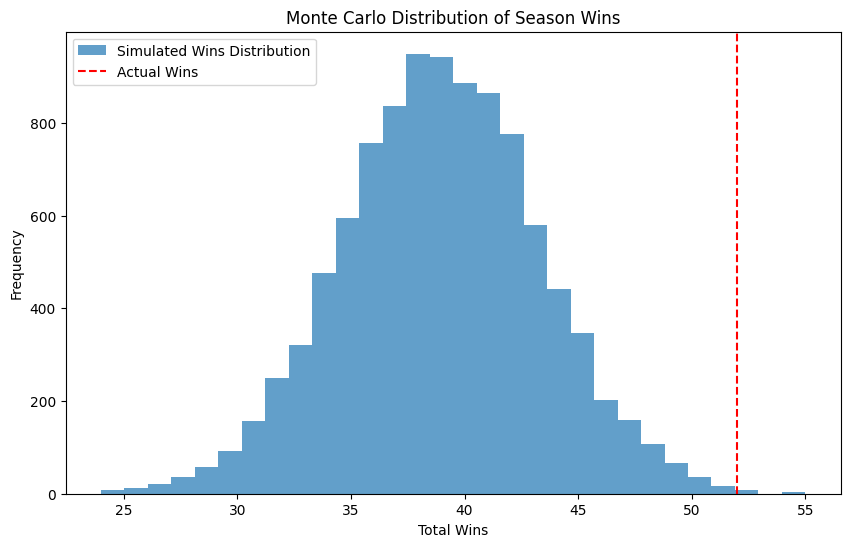

In [10]:
plt.figure(figsize=(10,6))
plt.hist(sim_wins, bins=30, alpha=0.7, label='Simulated Wins Distribution')
plt.axvline(total_actual_wins, color='r', linestyle='--', label='Actual Wins')
plt.xlabel('Total Wins')
plt.ylabel('Frequency')
plt.title('Monte Carlo Distribution of Season Wins')
plt.legend()
plt.show()

**Create a table for Season Metrics**

Calculate the standard dev and z scores to understand the significance of the findings

In [11]:
diff_wins = total_actual_wins - total_expected_wins
diff_GF = total_actual_GF - total_exp_GF
diff_GA = total_actual_GA - total_exp_GA

std_GF = np.sqrt(total_exp_GF)
std_GA = np.sqrt(total_exp_GA)
z_GF = diff_GF / std_GF if std_GF > 0 else 0
z_GA = diff_GA / std_GA if std_GA > 0 else 0

var_wins = sum(p * (1 - p) for p in df['exp_win_prob'])
std_wins = np.sqrt(var_wins)
z_wins = diff_wins / std_wins if std_wins > 0 else 0

In [12]:
print("Season Metrics:")
print(f"Actual Wins: {total_actual_wins}")
print(f"Expected Wins: {total_expected_wins:.2f}")
print(f"Difference in Wins: {diff_wins:.2f}")
print(f"Empirical p-value for wins: {p_wins:.4f}")
print(f"Z-Score for Wins: {z_wins:.2f}")
print(f"Actual Goals For: {total_actual_GF} (vs Expected {total_exp_GF:.2f}, Difference {diff_GF:.2f})")
print(f"Empirical p-value for GF: {p_GF:.4f}")
print(f"Z-Score for Goals For: {z_GF:.2f}")
print(f"Actual Goals Against: {total_actual_GA} (vs Expected {total_exp_GA:.2f}, Difference {diff_GA:.2f})")
print(f"Empirical p-value for GA: {p_GA:.4f}")
print(f"Z-Score for Goals Against: {z_GA:.2f}")

Season Metrics:
Actual Wins: 52
Expected Wins: 39.02
Difference in Wins: 12.98
Empirical p-value for wins: 0.0012
Z-Score for Wins: 3.10
Actual Goals For: 268 (vs Expected 249.97, Difference 18.03)
Empirical p-value for GF: 0.1290
Z-Score for Goals For: 1.14
Actual Goals Against: 231 (vs Expected 263.04, Difference -32.04)
Empirical p-value for GA: 0.0244
Z-Score for Goals Against: -1.98


**Discussion:**

The results of this metric show that the Maple Leafs far exceeded the poisson distributions prediction. For the full season, The Poisson predicted significantly less wins (39.02) compared to the actual wins (52). The z-score of 3.10 indicates that the observed wins were 3.10 standard deviations above the expected value, suggesting a highly statistically significant overperformance. This discrepancy in results could be from unmodeled factors such as above average play by players, coaching strategies, or simply luck that resulted in the excess wins. A deeper analysis of the individual factors and relative strengths of the team would be beneficial for a more accurate response.  

Regarding goal differential, the Poisson model underestimated goals for (+18.03 difference) and overestimated goals against (-32.04 difference), resulting in a net positive differential of approximately +50 goals. This large gap likely explains the underprediction of wins, as the team's defensive ability (fewer goals allowed) and offensive upside most likely correlated to more oportunities for a win.



# Part 3: Plot Information & Discuss

Create cumulative sums for actual win and expected win

In [13]:
df['cum_actual_wins'] = df['actual_win'].cumsum()
df['cum_exp_wins'] = df['exp_win_prob'].cumsum()

Plot Cumulative Wins

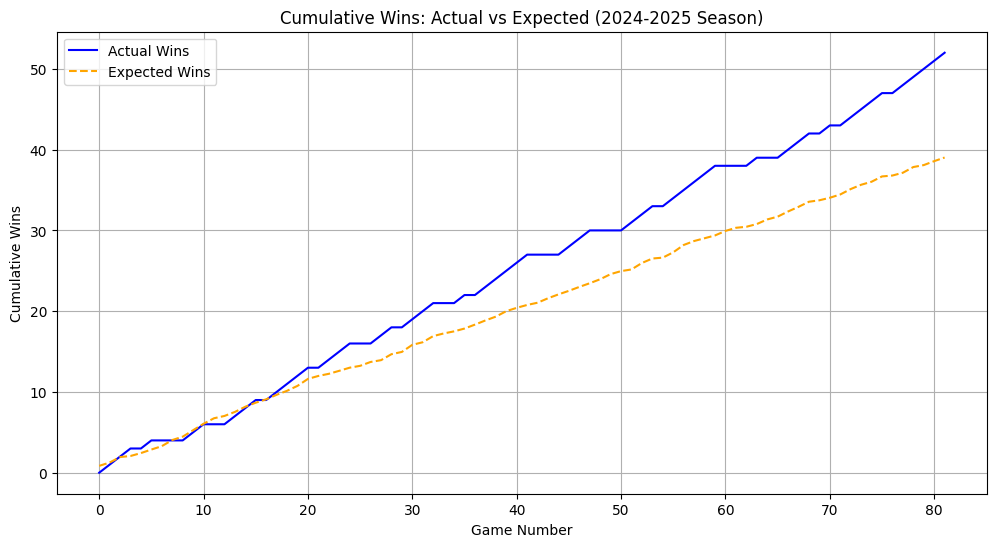

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df['cum_actual_wins'], label='Actual Wins', color='blue')
plt.plot(df['cum_exp_wins'], label='Expected Wins', color='orange', linestyle='--')
plt.title('Cumulative Wins: Actual vs Expected (2024-2025 Season)')
plt.xlabel('Game Number')
plt.ylabel('Cumulative Wins')
plt.legend()
plt.grid(True)
plt.show()

Looking at this graph, we can see that the at the begining of the season (games 1-20), the poisson distribution did a fairly accurate job at predicting wins. However, around games 15-20, the team significantly overperforms compared to the models predictions. This trend continues for the remainder of the season.

This graph displays our past discussion that the poisson distribution with monte carlo has underpredicted the actual results of the season.

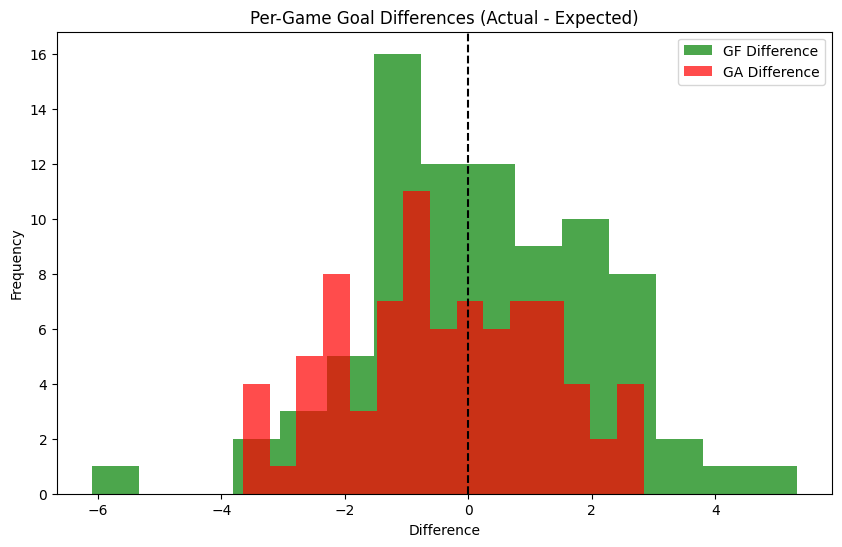

In [15]:
df['gf_diff'] = df['actual_GF'] - df['xGF']
df['ga_diff'] = df['actual_GA'] - df['xGA']
plt.figure(figsize=(10, 6))
plt.hist(df['gf_diff'], bins=15, alpha=0.7, label='GF Difference', color='green')
plt.hist(df['ga_diff'], bins=15, alpha=0.7, label='GA Difference', color='red')
plt.title('Per-Game Goal Differences (Actual - Expected)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--')
plt.legend()
plt.show()

This historgram shows the difference in GF and GA where 0 (dashed line) is where the actual goals f/a = expected.

Looking at the difference in goals for, we see that it is centred slightly above zero, relating to the fact that actual goals was higher then predicted. Moreover, some games had a large positive difference (~3 goals) while 1 game showed a large negative difference of -6.

Goals against seems to centre slightly left of zero which is consistent with the information that the actual GA was lower then the predicted. Based on the z-scores from previous (z score GF = 1.14, z score GA = -1.96), the goals against was more significant, meaning that their ability to prevent and save shots above expected won them more games.



# Limitations

The limitations of this model for predicting wins is that it only accounts for generalized offense and defensive statistics using xG. For a better model, we would want to implement team defining strengths such as goaltender quality (save percentages and goals against average) could be used.